# Финальное задание курса

В итоговом задании курса мы предлагаем вам решить задачу регрессии - по характеристикам поездок на такси в Нью-Йорке научиться определять их стоимость.

В задании две части:

* первая часть - обычная. Так устроены все ноутбуки с домашними заданиями в курсе. Мы что-то просим - вы делаете. Задания этой части как обычно проверяются тестами на Stepik

* вторая часть - творческая. В этой части мы даем вам лишь идеи того, что можно сделать, а все остальное - на вас. Это задание проверяется в виде текстового отчета (подробности смотрите в описании второй части задания)

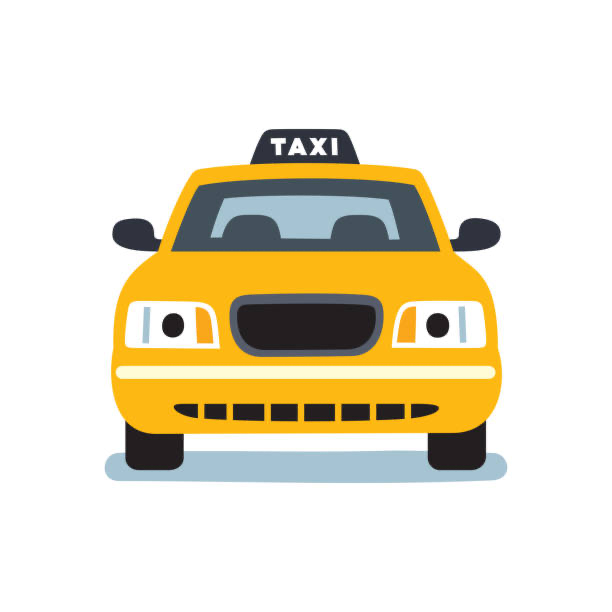

# Часть 1

In [72]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt

Считаем данные

In [73]:
df = pd.read_csv("https://www.dropbox.com/s/glmbcyopi24m2ni/final_project_data.csv?dl=1")

df.head()

,key,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count,fare_amount
0,2011-11-23 14:36:35.0000003,2011-11-23 14:36:35 UTC,-73.959075,40.783316,-73.959087,40.783345,1.0,2.5
1,2013-09-14 21:40:00.00000016,2013-09-14 21:40:00 UTC,-73.931612,40.771060,-73.929097,40.760542,1.0,5.5
2,2012-04-30 18:13:19.0000002,2012-04-30 18:13:19 UTC,-73.997929,40.740983,-74.007197,40.727725,2.0,6.5
3,2010-10-22 15:03:47.0000001,2010-10-22 15:03:47 UTC,-73.980608,40.742449,-73.985609,40.755807,1.0,6.5
4,2011-02-18 18:08:16.0000002,2011-02-18 18:08:16 UTC,-74.008884,40.720314,-73.983280,40.722350,1.0,12.1


## Исследование данных

### Quiz

Сколько строк в таблице df?

In [74]:
df.shape

(615962, 8)

### Quiz

Есть ли пропущенные значения в таблице? В скольких столбцах есть пропуски?

In [75]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 615962 entries, 0 to 615961
Data columns (total 8 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   key                615962 non-null  object 
 1   pickup_datetime    615962 non-null  object 
 2   pickup_longitude   615962 non-null  float64
 3   pickup_latitude    615961 non-null  float64
 4   dropoff_longitude  615959 non-null  float64
 5   dropoff_latitude   615959 non-null  float64
 6   passenger_count    615961 non-null  float64
 7   fare_amount        615961 non-null  float64
dtypes: float64(6), object(2)
memory usage: 37.6+ MB


### Quiz

Удалите строки с пропущенными значениями из таблицы. Сколько строк осталось в таблице?

In [76]:
df = df.dropna()
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 615959 entries, 0 to 615960
Data columns (total 8 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   key                615959 non-null  object 
 1   pickup_datetime    615959 non-null  object 
 2   pickup_longitude   615959 non-null  float64
 3   pickup_latitude    615959 non-null  float64
 4   dropoff_longitude  615959 non-null  float64
 5   dropoff_latitude   615959 non-null  float64
 6   passenger_count    615959 non-null  float64
 7   fare_amount        615959 non-null  float64
dtypes: float64(6), object(2)
memory usage: 42.3+ MB


Удалите из данных колонку `key`, так как в ней дублируется информация из `pickup_datetime`

In [77]:
df = df.drop(columns=['key'])

Обработайте колонку `pickup_datetime`. Выделите из нее 4 новых столбца:

* `year` - год поездки
* `month` - месяц поездки
* `day` - день поездки
* `hour` - час поездки. Час вычисляйте так: если до следующего часа осталось меньше 30 минут (на секунды не смотрим), что час округляете до следующего.

Пример: 14:18:20 -> 14 часов, 17:48:29 -> 18 часов

Затем удалите столбец `pickup_datetime`.



In [78]:
df['pickup_datetime'] = pd.to_datetime(df['pickup_datetime'])
df['pickup_datetime']

,pickup_datetime
0,2011-11-23 14:36:35+00:00
1,2013-09-14 21:40:00+00:00
2,2012-04-30 18:13:19+00:00
3,2010-10-22 15:03:47+00:00
4,2011-02-18 18:08:16+00:00
...,...
615956,2013-12-01 00:21:40+00:00
615957,2014-05-06 20:19:00+00:00
615958,2012-01-31 00:16:00+00:00
615959,2014-07-28 00:03:00+00:00


In [79]:
df['year'] = df['pickup_datetime'].dt.year
df['month'] = df['pickup_datetime'].dt.month
df['day'] = df['pickup_datetime'].dt.day
df['hour'] = df['pickup_datetime'].dt.hour

In [80]:
df.drop(columns='pickup_datetime', inplace=True)

## Вопросы по данным

### Quiz

В какие годы совершались поездки?

In [81]:
df['year'].value_counts()

,count
year,
2012,99060
2011,97898
2013,96329
2009,94465
2010,93419
2014,92051
2015,42737


### Quiz

В какой час было совершено больше всего поездок?

In [82]:
df['hour'].mode()

,hour
0,19


### Quiz

В какой сезон (зима, весна, лето, осень) было совершено наименьшее число поездок?

In [ ]:
df['season'] = df['month'] // 3
df.loc[df['season'] == 4, 'season'] = 0
df['season'].value_counts()

,count
season,
1,172242
0,153973
2,146371
3,143373


In [84]:
df.drop(columns=['season'], inplace=True)

Постройте scatter plot в осях `pickup_latitude` и `pickup_longitude`

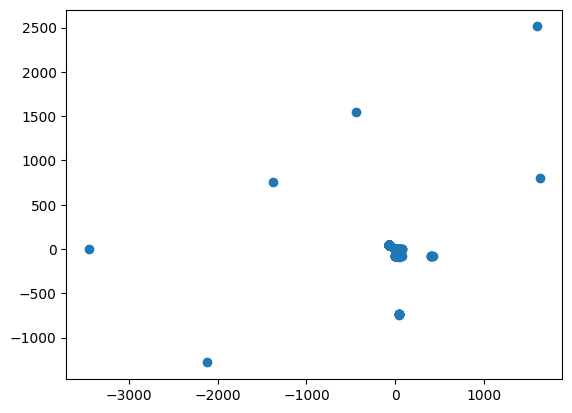

In [85]:
plt.scatter(df['pickup_latitude'], df['pickup_longitude'])
plt.show()

### Quiz

Постройте ящик с усами boxplot для `pickup_longitude`. Есть ли на визуализации выбросы? (отдельные точки)

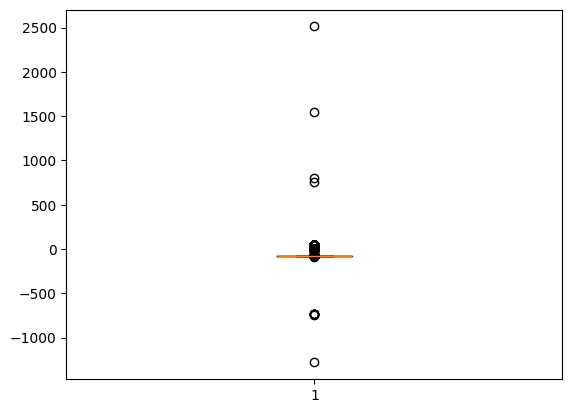

In [86]:
plt.boxplot(df['pickup_longitude'])
plt.show()

### Quiz

Чему равна медиана `pickup_longitude`? Ответ округлите до тысячных.

In [87]:
df.describe()

,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count,fare_amount,year,month,day,hour
count,615959.000000,615959.000000,615959.000000,615959.000000,615959.000000,615959.000000,615959.000000,615959.000000,615959.000000,615959.000000
mean,-72.528287,39.932560,-72.531908,39.917904,1.685127,11.332180,2011.741072,6.263397,15.705920,13.512912
std,11.517516,8.754114,11.829973,10.339851,1.309251,9.743292,1.859415,3.434892,8.684416,6.512433
min,-1280.547368,-3447.915090,-3328.756240,-3493.651853,0.000000,-45.000000,2009.000000,1.000000,1.000000,0.000000
25%,-73.992078,40.735004,-73.991380,40.734070,1.000000,6.000000,2010.000000,3.000000,8.000000,9.000000
50%,-73.981803,40.752714,-73.980167,40.753212,1.000000,8.500000,2012.000000,6.000000,16.000000,14.000000
75%,-73.967087,40.767184,-73.963688,40.768120,2.000000,12.500000,2013.000000,9.000000,23.000000,19.000000
max,2512.533050,1629.004200,2058.322398,1640.072227,6.000000,370.000000,2015.000000,12.000000,31.000000,23.000000


Постройте гистограмму распределения признака `hour`.

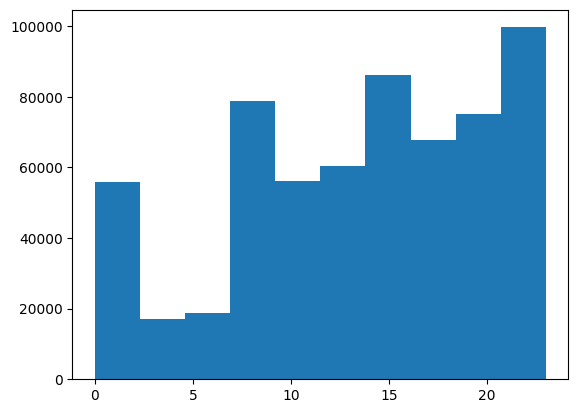

In [88]:
plt.hist(df['hour'])
plt.show()

## Построение baseline-модели

Разбейте `df` на матрицу объект-признак `X` и вектор с целевой переменной `y`. Целевая переменная - столбец `fare_amount`.

In [89]:
X = df.drop(columns=['fare_amount'])
y = df['fare_amount']

Разбейте данные на тренировочную и тестовую части с помощью train_test_split.

Тестовая часть - 25% всех данных, `random_state=42`.

Сколько строк в матрице `X_train`?

In [90]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

In [91]:
X_train.shape

(461969, 9)

### Quiz

Обучите решающее дерево глубины 3 на тренировочных данных и вычислите ошибку $R^2$ на тесте. Ответ округлите до сотых.

Зафиксируйте у дерева `random_state=42`.

In [92]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import r2_score

dt = DecisionTreeRegressor(max_depth=3, random_state=42)

dt.fit(X_train, y_train)
dt_pred = dt.predict(X_test)

dt_r2 = r2_score(y_test, dt_pred)
dt_r2

0.4998349394485503

### Quiz

Постройте гистограмму важности признаков.

Какой признак имеет наибольший вес?

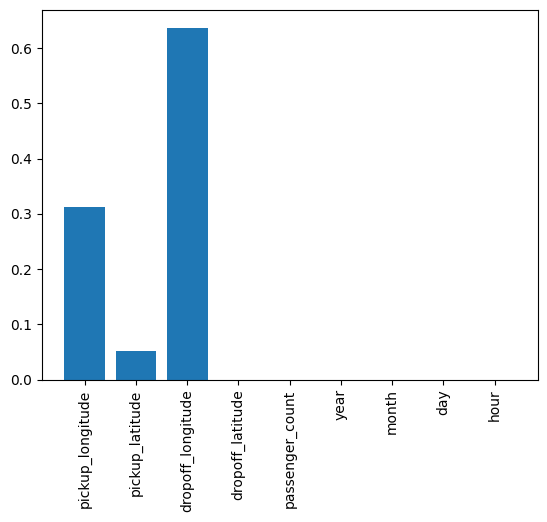

In [93]:
fi = dt.feature_importances_

plt.bar(X_train.columns, fi)
plt.xticks(rotation=90)
plt.show()

## Улучшение модели

### Quiz

Постройте гистограмму распределения целевой переменной `y`, укажите параметр `bins=100`.

Является ли распределение нормальным?

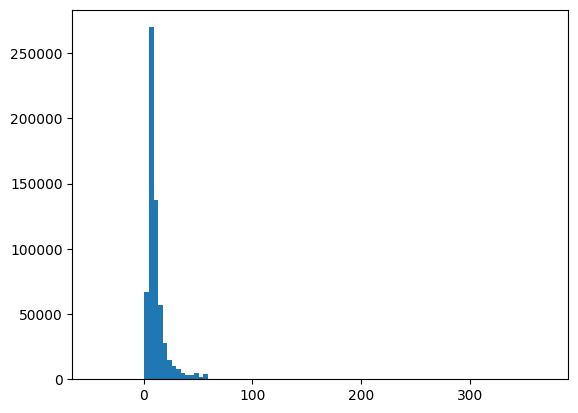

In [94]:
plt.hist(y, bins=100)
plt.show()

Замените все значения $y$, меньшие 0, на 0.

Сделайте преобразование целевой переменной по правилу $y_{new} = np.log1p(y)$

Заново разбейте данные на тренировочную и тестовую часть по тем же правилам, что и раньше, но теперь используйте `X` и `y_new`.

In [95]:
y.loc[y < 0] = 0
y_new = np.log1p(y)

/tmp/ipykernel_21780/2012360156.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  y.loc[y < 0] = 0


In [96]:
X_train, X_test, y_train, y_test = train_test_split(X, y_new, test_size=0.25, random_state=42)

### Quiz

Заново обучите решающее дерево глубины 3 с `random_state=42` на тренировочных данных и вычислите $R^2$ на тесте. Ответ округлите до сотых.

Перед вычислением $R^2$ сделайте обратное преобразование от прогноза: `np.expm1(pred)` и от `y_test`.

**Важно:** дальше мы будем работать с преобразованной целевой переменной, поэтому при вычислении $R^2$ во всех заданиях ниже делайте обратное преобразование.

In [97]:
dt = DecisionTreeRegressor(max_depth=3, random_state=42)

dt.fit(X_train, y_train)
dt_pred = dt.predict(X_test)

r2_score(np.expm1(y_test), np.expm1(dt_pred))

0.4434601265690862

### Quiz


Подберите по кросс-валидации на тренировочных данных глубину дерева в диапазоне от 3 до 10 включительно с шагом 1 (`random_state=42`).

`cv=3, scoring=r2`

Затем примените модель с оптимальной глубиной на тесте и вычислите $R^2$. Ответ округлите до сотых.

Перед вычислением $R^2$ не забудьте (как и дальше) делать преобразование `np.expm1`

In [98]:
from sklearn.model_selection import GridSearchCV

params = {
    'max_depth': np.arange(3, 11)
}

gs = GridSearchCV(DecisionTreeRegressor(random_state=42), params, cv=3, scoring='r2')
gs.fit(X_train, y_train)

gs_pred = gs.predict(X_test)
r2_score(np.expm1(y_test), np.expm1(gs_pred))

0.6884384279126998

## Усложнение пайплайна

Создайте pipeline, в котором сначала извлеките полиномиальные признаки степени 2 из данных, а затем обучите решающее дерево глубины 3 с `random_state=42`.

In [99]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures

p1 = Pipeline([
    ('features', PolynomialFeatures(degree=2)),
    ('model', DecisionTreeRegressor(max_depth=3, random_state=42))
])

### Quiz

Обучите pipeline на тренировочных данных, сделайте прогноз на тесте и вычислите $R^2$. Ответ округлите до сотых.

In [100]:
p1.fit(X_train, y_train)
r2_score(np.expm1(y_test), np.expm1(p1.predict(X_test))) 

0.4173231422216578

При помощи GridSearchCV с теми же гиперпараметрами, что и раньше, подберите глубину дерева внутри пайплайна в диапазоне от 3 до 10 включительно с шагом 1.

### Quiz

Выведите $R^2$ лучшего результата на тесте. Ответ округлите до сотых.

In [101]:
params = {
    'model__max_depth': np.arange(3, 11)
}

gs = GridSearchCV(p1, params, cv=3, scoring='r2')
gs.fit(X_train, y_train)

GridSearchCV(cv=3,
             estimator=Pipeline(steps=[('features', PolynomialFeatures()),
                                       ('model',
                                        DecisionTreeRegressor(max_depth=3,
                                                              random_state=42))]),
             param_grid={'model__max_depth': array([ 3,  4,  5,  6,  7,  8,  9, 10])},
             scoring='r2')

In [102]:
gs_pred = gs.predict(X_test)
r2_score(np.expm1(y_test), np.expm1(gs_pred))

0.7141815704902021

## Feature selection

Добавьте в предыдущий пайплайн:
* после добавления полиномиальных признаков - StandardScaler
* затем - снижение размерности при помощи метода `SelectFromModel` с моделью `Ridge` с гиперпараметрами по умолчанию.

In [103]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectFromModel
from sklearn.linear_model import Lasso, Ridge

p2 = Pipeline([
    ('features', PolynomialFeatures(degree=2)),
    ('scaler', StandardScaler()),
    ('selector', SelectFromModel(estimator=Ridge())),
    ('model', DecisionTreeRegressor(max_depth=10, random_state=42))
])

Обучите пайплайн на тренировочных данных, сделайте прогноз на тесте и вычислите для него $R^2$.

In [104]:
p2.fit(X_train, y_train)
p2_pred = p2.predict(X_test)
r2_score(np.expm1(y_test), np.expm1(p2_pred))

0.7106256590062794

Подберите глубину решающего дерева в пайплайне, в том же диапазоне и теми же гиперпараметрами GridSearch, что и в предыдущих заданиях.

Вычислите $R^2$ на тестовых данных, ответ округлите до сотых.

In [105]:
params = {
    'model__max_depth': np.arange(3, 11)
}

gs2 = GridSearchCV(p2, params, cv=3, scoring='r2')
gs2.fit(X_train, y_train)

GridSearchCV(cv=3,
             estimator=Pipeline(steps=[('features', PolynomialFeatures()),
                                       ('scaler', StandardScaler()),
                                       ('selector',
                                        SelectFromModel(estimator=Ridge())),
                                       ('model',
                                        DecisionTreeRegressor(max_depth=10,
                                                              random_state=42))]),
             param_grid={'model__max_depth': array([ 3,  4,  5,  6,  7,  8,  9, 10])},
             scoring='r2')

In [106]:
gs2_pred = gs2.predict(X_test)
r2_score(np.expm1(y_test), np.expm1(gs2_pred))

0.7106256590062794

### Quiz

Удалось ли при помощи пайплайна с отбором признаков улучшить результат предыдущей лучшей модели?

## Кодирование категориальных признаков

Признаки `month`, `day`, `hour` - категориальные (подумайте почему!)

Поэтому их можно попробовать закодировать.

Попробуем подход: группировка значений признака + дальнейшая OneHot-кодировка.

* Создайте колонки `winter`, `spring`, `summer`, `autumn` - в каждую из которых пишите 1, если месяц относится к сезону, и 0 иначе.

* Создайте колонки `start_month`, `middle_month`, `end_month` - в каждую колонку пишите 1, если день относится к началу месяца (1-10 число), середине месяца (11-20 число), концу месяца (от 21 числа), и 0 иначе.

* Создайте колонки `night`, `morning`, `day`, `evening` по аналогии. Если час - от 23 до 5, то это `night`, от 6 до 11 - `morning`, от 12 до 16 - `day`, от 17 до 22 - `evening`.

После создания новых колонок удалите колонки `month`, `day`, `hour`.

P.S. Отдельно делайте преобразования для X_train и для X_test, чтобы заново не разбивать данные.

In [110]:
for curr_df in [X_train, X_test]:
    curr_df['season'] = curr_df['month'] // 3
    curr_df.loc[curr_df['season'] == 4, 'season'] = 0

    curr_df['winter'] = (curr_df['season'] == 0).astype(int)
    curr_df['spring'] = (curr_df['season'] == 1).astype(int)
    curr_df['summer'] = (curr_df['season'] == 2).astype(int)
    curr_df['autumn'] = (curr_df['season'] == 3).astype(int)

    curr_df.drop(columns=['month', 'season'], inplace=True)

In [ ]:
for curr_df in [X_train, X_test]:
    curr_df['start_month'] = (curr_df['day'] <= 10).astype(int)
    curr_df['middle_month'] = ((curr_df['day'] > 10) & (curr_df['day'] <= 20)).astype(int)
    curr_df['end_month'] = (curr_df['day'] > 20).astype(int)

    curr_df.drop(columns=['day'], inplace=True)

In [ ]:
for curr_df in [X_train, X_test]:
    curr_df['night'] = ((curr_df['hour'] <= 5) & (curr_df['hour'] >= 23)).astype(int)
    curr_df['morning'] = ((curr_df['hour'] >= 6)  & (curr_df['hour'] <= 11)).astype(int)
    curr_df['day'] = ((curr_df['hour'] >= 12)  & (curr_df['hour'] <= 16)).astype(int)
    curr_df['evening'] = ((curr_df['hour'] >= 17)  & (curr_df['hour'] <= 22)).astype(int)

    curr_df.drop(columns=['hour'], inplace=True)

In [115]:
X_train

,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count,year,winter,spring,summer,autumn,start_month,middle_month,end_month,night,morning,day,evening
537483,-73.984460,40.720162,-73.984322,40.731110,1.0,2011,0,0,0,1,True,False,False,False,False,False,True
543146,-73.937375,40.804540,-73.960572,40.807480,2.0,2013,0,1,0,0,False,True,False,False,False,False,True
575883,-73.925792,40.744198,-73.918459,40.765595,1.0,2010,1,0,0,0,False,False,True,False,True,False,False
66928,-74.003342,40.722141,-74.015869,40.715488,5.0,2015,1,0,0,0,False,True,False,False,True,False,False
164891,-73.991783,40.749656,-73.979164,40.740610,1.0,2011,0,0,0,1,False,False,True,False,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
110269,-73.980885,40.774412,-74.004750,40.734807,1.0,2013,0,1,0,0,False,False,True,False,False,False,True
259179,-73.956220,40.778587,-73.980752,40.744727,1.0,2014,0,1,0,0,True,False,False,False,True,False,False
365839,-73.994867,40.740037,-74.004692,40.741732,1.0,2009,0,0,1,0,True,False,False,False,False,False,True
131933,-73.954971,40.780151,-73.972580,40.781116,3.0,2015,0,1,0,0,False,False,True,False,False,True,False


### Quiz

На сколько признаков стало больше в матрице-объект признак после добавления закодированных категориальных столбцов и удаления исходных категориальных столбцов?

Подберите при помощи GridSearch с теми же гиперпараметрами, что и выше, оптимальную глубину дерева в диапазоне от 3 до 10 включительно (с шагом 1). У дерева `random_state=42`.

In [118]:
params = {
    'max_depth': np.arange(3, 11)
}

gs = GridSearchCV(DecisionTreeRegressor(random_state=42), params, cv=3, scoring='r2')
gs.fit(X_train, y_train)
pred = gs.predict(X_test)
r2_score(y_test, pred)

0.5694577342223319

Постройте гистограмму важности признаков для полученной модели (лучшей по GridSearch).

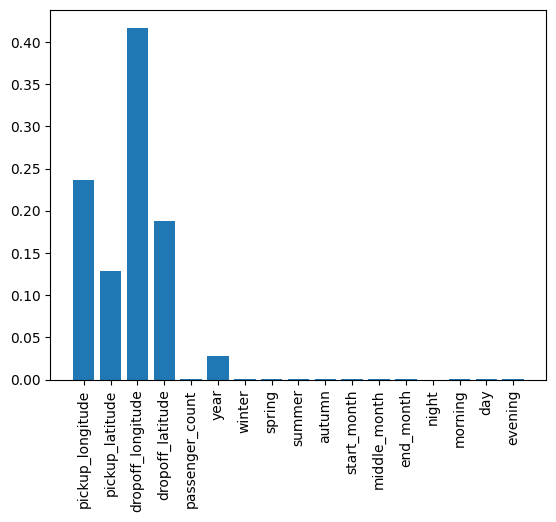

In [121]:
fi = gs.best_estimator_.feature_importances_

plt.bar(X_train.columns, fi)
plt.xticks(rotation=90)
plt.show()

### Quiz

Какой из признаков, связанных с датой поездки, самый важный для модели?

## Кластеризация и визуализация

Оставьте только те строчки в таблице df (после удаления пропусков), для которых выполнены оба условия:

* `dropoff_latitude` $\in (39;41)$
* `dropoff_longitude` $\in (-75;-72)$

### Quiz

Сколько строк осталось в таблице?

In [122]:
df = df[(df['dropoff_latitude'] > 39) & (df['dropoff_latitude'] < 41) & (df['dropoff_longitude'] > -75) & (df['dropoff_longitude'] < -72)]
df.shape

(603729, 10)

Разбейте все поездки по признакам `dropoff_latitude`, `dropoff_longitude` на 5 кластеров.

Используйте kmeans c `random_state=42`.

Визуализируйте поездки из таблицы df в осях `dropoff_latitude`, `dropoff_longitude` - покрасьте точки в цвета, соответствующие кластерам.

In [124]:
from sklearn.cluster import KMeans

X = df[['dropoff_latitude', 'dropoff_longitude']]
km = KMeans(n_clusters=5, random_state=42)

km.fit(X)

df['cluster'] = km.labels_

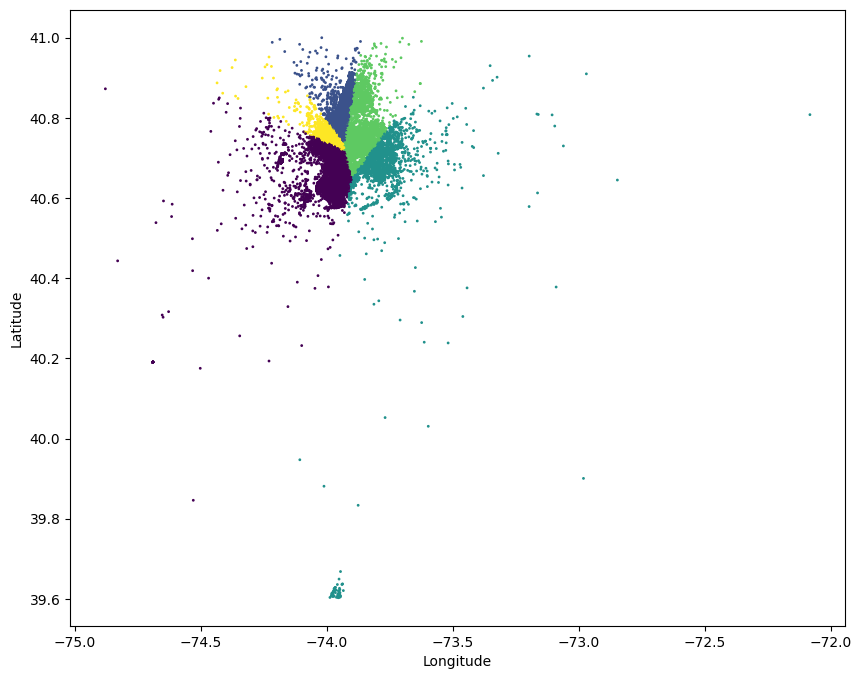

In [125]:
plt.figure(figsize=(10, 8))

plt.scatter(
    df['dropoff_longitude'],
    df['dropoff_latitude'],
    c=df['cluster'],
    s=1
)

plt.xlabel('Longitude')
plt.ylabel('Latitude')

plt.show()

### Quiz

Для каждого кластера вычислите среднюю стоимость поездки.

Чему равна самая большая средняя стоимость поездки по кластерам? Ответ округлите до целого числа.

In [126]:
df

,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count,fare_amount,year,month,day,hour,cluster
0,-73.959075,40.783316,-73.959087,40.783345,1.0,2.5,2011,11,23,14,1
1,-73.931612,40.771060,-73.929097,40.760542,1.0,5.5,2013,9,14,21,1
2,-73.997929,40.740983,-74.007197,40.727725,2.0,6.5,2012,4,30,18,0
3,-73.980608,40.742449,-73.985609,40.755807,1.0,6.5,2010,10,22,15,4
4,-74.008884,40.720314,-73.983280,40.722350,1.0,12.1,2011,2,18,18,0
...,...,...,...,...,...,...,...,...,...,...,...
615956,-73.979049,40.736143,-73.980528,40.730353,1.0,5.5,2013,12,1,0,0
615957,-73.976600,40.745290,-73.980242,40.759672,2.0,10.5,2014,5,6,20,4
615958,-73.987750,40.745760,-73.953092,40.776787,1.0,10.9,2012,1,31,0,1
615959,-73.983165,40.728207,-74.002797,40.728670,1.0,7.5,2014,7,28,0,0


In [127]:
df.groupby('cluster')['fare_amount'].mean()

,fare_amount
cluster,
0,12.549306
1,10.347561
2,40.102965
3,23.921432
4,9.582697


Отдельно нарисуйте кластер с наибольшей средней стоимостью поездки. В нем выделяется два островка.

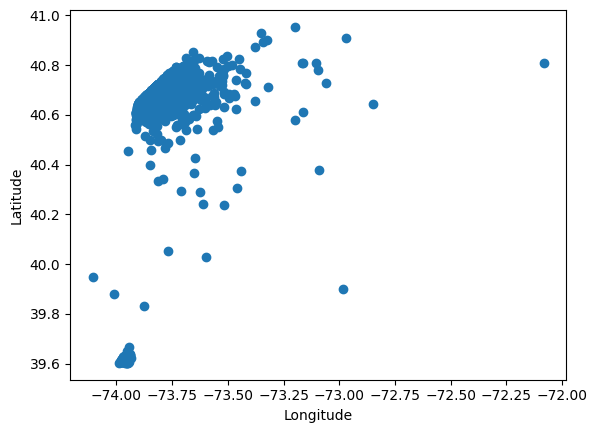

In [128]:
plt.scatter(
    df.loc[df['cluster'] == 2,'dropoff_longitude'],
    df.loc[df['cluster'] == 2, 'dropoff_latitude']
)

plt.xlabel('Longitude')
plt.ylabel('Latitude')

plt.show()

### Quiz

Кластеризуйте точки этого кластера при помощи DBSCAN с гиперпараметрами `eps`=0.15, `min_samples`=10.

Нарисуйте результат.

Вычислите координаты центра (среднее арифметрическое) меньшего кластера.

В ответе укажите `dropoff_latitude`, округленную до тысячных.

In [132]:
from sklearn.cluster import DBSCAN

X = df.loc[df['cluster'] == 2, ['dropoff_longitude', 'dropoff_latitude']]
dbs = DBSCAN(eps=0.15, min_samples=10)

dbs.fit(X)

X['labels'] = dbs.labels_

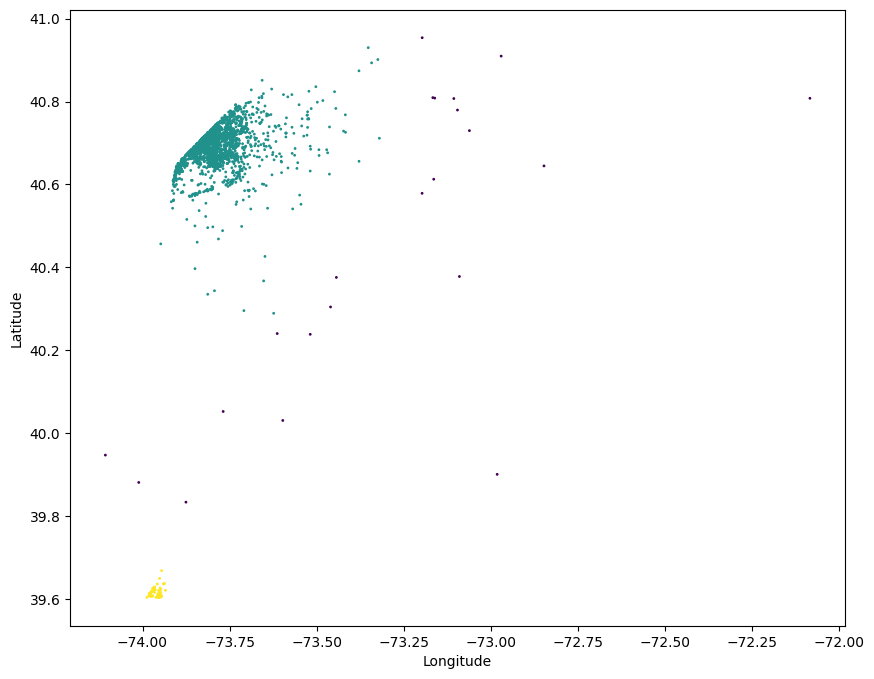

In [133]:
plt.figure(figsize=(10, 8))

plt.scatter(
    X['dropoff_longitude'],
    X['dropoff_latitude'],
    c=X['labels'],
    s=1
)

plt.xlabel('Longitude')
plt.ylabel('Latitude')

plt.show()

In [137]:
X.loc[X['labels'] == 1, 'dropoff_latitude'].mean()

np.float64(39.6163248012393)